In [ ]:
!pip install pytorch-tabnet xgboost lightgbm

In [ ]:
import pandas as pd
import numpy as np
import os
import random
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, log_loss
import xgboost as xgb
import lightgbm as lgb
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
import time
import matplotlib.pyplot as plt


In [ ]:
# Mengunci random seeds

def seed_everything(seed=42):
    # Kunci Python built-in random
    random.seed(seed)

    # Kunci Environment Hash
    os.environ['PYTHONHASHSEED'] = str(seed)

    # Kunci Numpy random
    np.random.seed(seed)

    # Kunci PyTorch random
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Buat PyTorch deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Panggil fungsinya
seed_everything(42)

In [ ]:
#load data
train_df = pd.read_csv('train.csv', thousands=',')
test_df = pd.read_csv('test.csv', thousands=',')

In [ ]:
# drop beberapa kolom yg ga kepake
X = train_df.drop(columns=['Stock code', 'IsDefault'])
y = train_df['IsDefault']
X_test_sub = test_df.drop(columns=['Stock code'])


In [ ]:
# split data training dan testing
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#impute tree models (Xgboost dan lightgbm)
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test_sub)

In [ ]:
# scaling utk standardisasi dataset tabnet
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

In [ ]:
# Function buat nyimpen model dan hasil
models_dict = {}
auc_scores = {}
cms = [] # List buat nyimpen matriks buat di-plot nanti
model_names = ['LightGBM', 'XGBoost', 'TabNet']

In [ ]:
# Function buat print evaluasi
def evaluate_and_plot(name, y_true, y_pred, y_prob, history):
    print(f"\n{'='*40}\n📊 REPORT EVALUASI: {name} 📊\n{'='*40}")
    print(f"ROC-AUC Score : {roc_auc_score(y_true, y_prob):.4f}")
    print("-" * 40)
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot 1: Confusion Matrix
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={"size": 14})
    axes[0].set_title(f'Confusion Matrix: {name}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Prediksi (0=Aman, 1=Gagal)')
    axes[0].set_ylabel('Aktual (0=Aman, 1=Gagal)')

    # Plot 2: Learning Curve (Loss)
    if name == 'LightGBM':
        train_loss = history['training']['binary_logloss']
        val_loss = history['valid_1']['binary_logloss']
    elif name == 'XGBoost':
        train_loss = history['validation_0']['logloss']
        val_loss = history['validation_1']['logloss']
    elif name == 'TabNet':
        train_loss = history['loss']

        try:
            val_loss = history['val_1_logloss'] # Kalau masukin Train & Val ke eval_set
        except KeyError:
            val_loss = history['val_0_logloss'] # Kalau cuma masukin Val ke eval_set

    axes[1].plot(train_loss, label='Training Loss', color='#e74c3c', linewidth=2)
    axes[1].plot(val_loss, label='Validation Loss', color='#2980b9', linewidth=2)
    axes[1].set_title(f'Learning Curve (Log Loss): {name}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Iterasi / Epoch')
    axes[1].set_ylabel('Error (Makin kecil makin bagus)')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

[LightGBM] [Info] Number of positive: 213, number of negative: 940
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10202
[LightGBM] [Info] Number of data points in the train set: 1153, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.184735 -> initscore=-1.484588
[LightGBM] [Info] Start training from score -1.484588
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


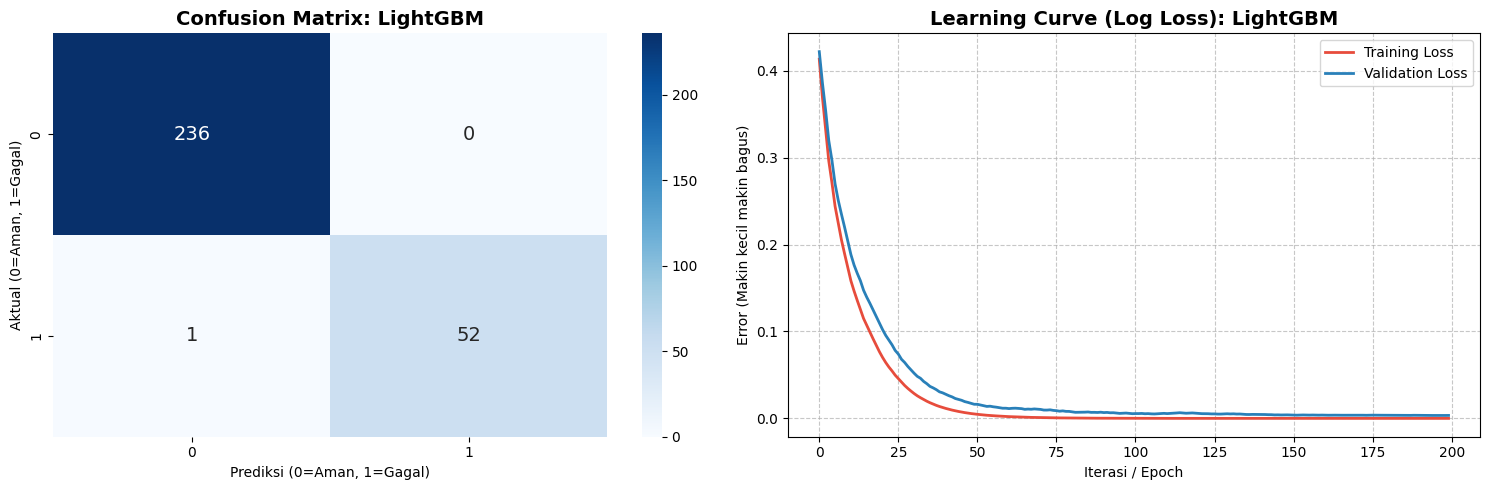

In [ ]:
#Training model LightGBM
start_time = time.time()
lgb_model = lgb.LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1)

lgb_model.fit(
    X_train_imp, y_train,
    eval_set=[(X_train_imp, y_train), (X_val_imp, y_val)],
    eval_metric='logloss',
    callbacks=[lgb.log_evaluation(0)]
)

lgb_probs = lgb_model.predict_proba(X_val_imp)[:, 1]
lgb_preds = lgb_model.predict(X_val_imp)

auc_scores['LightGBM'] = roc_auc_score(y_val, lgb_probs)

# Visualisasi
history_lgb = lgb_model.evals_result_
evaluate_and_plot('LightGBM', y_val, lgb_preds, lgb_probs, history_lgb)


📊 REPORT EVALUASI: XGBoost 📊
ROC-AUC Score : 1.0000
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       236
           1       1.00      0.94      0.97        53

    accuracy                           0.99       289
   macro avg       0.99      0.97      0.98       289
weighted avg       0.99      0.99      0.99       289



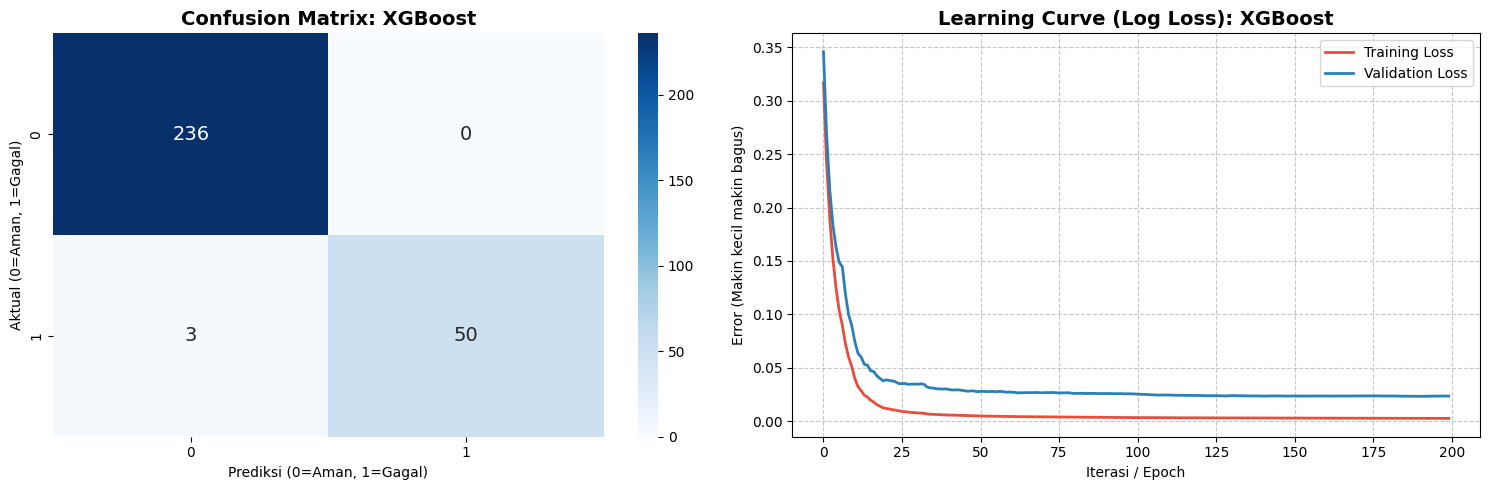

In [ ]:
#Training model XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss', n_jobs=-1)

xgb_model.fit(
    X_train_imp, y_train,
    eval_set=[(X_train_imp, y_train), (X_val_imp, y_val)],
    verbose=False
)

xgb_probs = xgb_model.predict_proba(X_val_imp)[:, 1]
xgb_preds = xgb_model.predict(X_val_imp)

auc_scores['XGBoost'] = roc_auc_score(y_val, xgb_probs)

# Visualisasi
history_xgb = xgb_model.evals_result()
evaluate_and_plot('XGBoost', y_val, xgb_preds, xgb_probs, history_xgb)

Stop training because you reached max_epochs = 50 with best_epoch = 45 and best_val_1_auc = 0.89231

📊 REPORT EVALUASI: TabNet 📊
ROC-AUC Score : 0.8923
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       236
           1       0.69      0.58      0.63        53

    accuracy                           0.88       289
   macro avg       0.80      0.76      0.78       289
weighted avg       0.87      0.88      0.87       289



/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


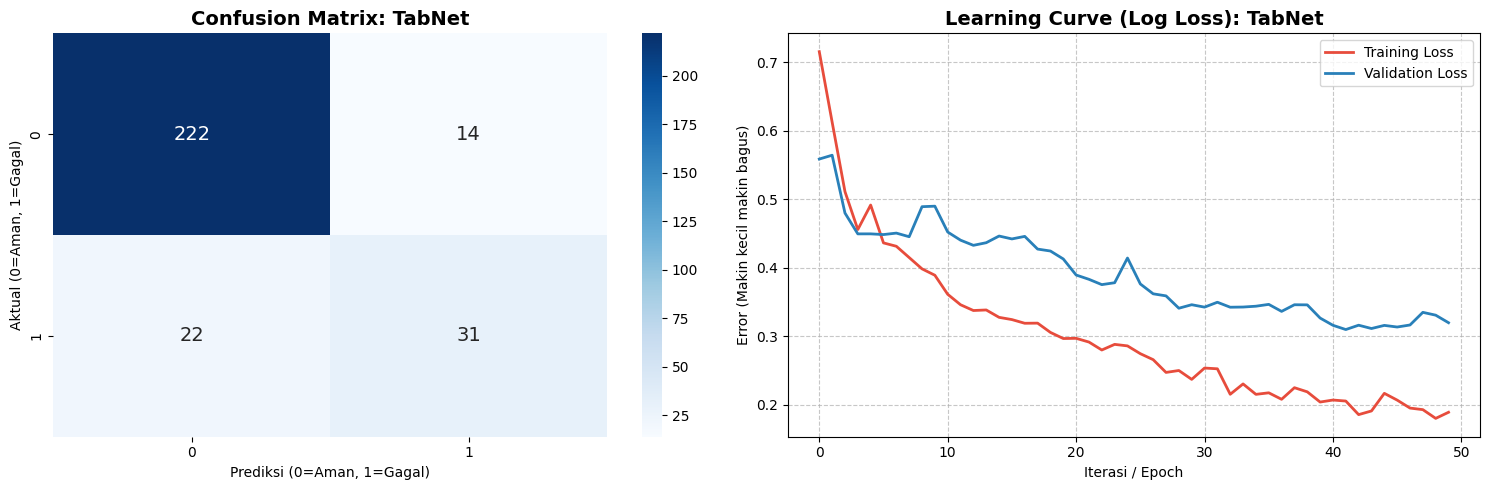

In [ ]:
#Training model TabNet
tabnet_model = TabNetClassifier(
    optimizer_fn=torch.optim.Adam, optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":10, "gamma":0.9}, scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax', verbose=0
)

tabnet_model.fit(
    X_train=X_train_scaled, y_train=y_train.values,
    eval_set=[(X_train_scaled, y_train.values), (X_val_scaled, y_val.values)],
    eval_metric=['logloss', 'auc'],
    max_epochs=50, patience=10, batch_size=256, virtual_batch_size=128
)

tabnet_probs = tabnet_model.predict_proba(X_val_scaled)[:, 1]
tabnet_preds = tabnet_model.predict(X_val_scaled)

auc_scores['TabNet'] = roc_auc_score(y_val, tabnet_probs)

# Visualisasi
history_tabnet = tabnet_model.history
evaluate_and_plot('TabNet', y_val, tabnet_preds, tabnet_probs, history_tabnet)

In [ ]:
# Menentukan model mana yg terbaik

# Menghitung log loss tiap model
logloss_scores = {
    'LightGBM': log_loss(y_val, lgb_probs),
    'XGBoost': log_loss(y_val, xgb_probs),
    'TabNet': log_loss(y_val, tabnet_probs)
}

# Sorting log loss ascending
sorted_models = sorted(logloss_scores.items(), key=lambda x: x[1])

for i, (model, ll_score) in enumerate(sorted_models, 1):
    auc_val = auc_scores[model] # Ambil nilai AUC yang udah kesimpen
    print(f"{i}. {model.ljust(10)} : Log Loss = {ll_score:.4f}  |  AUC = {auc_val:.4f}")



1. LightGBM   : Log Loss = 0.0034  |  AUC = 1.0000
2. XGBoost    : Log Loss = 0.0235  |  AUC = 1.0000
3. TabNet     : Log Loss = 0.3132  |  AUC = 0.8923


In [ ]:
# 3. Menentukan model yg terbaik berdasarkan log loss terkecil
best_model_name = sorted_models[0][0]
print(f"\n Model terbaik: {best_model_name} ")


 Model terbaik: LightGBM 


In [ ]:
# 4. Model terbaik yg terpilih
if best_model_name == 'LightGBM':
    final_preds = lgb_model.predict(X_test_imp)
elif best_model_name == 'XGBoost':
    final_preds = xgb_model.predict(X_test_imp)
else:
    final_preds = tabnet_model.predict(X_test_scaled)

# 5. Export file
submission = pd.DataFrame({'Stock code': test_df['Stock code'], 'IsDefault': final_preds})
file_name = f'submission_final_{best_model_name.lower()}.csv'
submission.to_csv(file_name, index=False)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
